In [13]:
import os
print(os.getcwd())

/Users/aman/Documents/DAI-Summer-Term/Causal_inference


In [14]:
import pandas as pd

df = pd.read_csv('../data/Polymarkets_Data_Cleaned.csv')
print(df.shape)
print(df.columns.tolist())
print(df.head(3))

(200000, 33)
['id', 'question', 'startDateIso', 'endDateIso', 'volume', 'liquidity', 'outcomes', 'outcomePrices', 'competitive', 'rewardsMinSize', 'restricted', 'spread_poly', 'bestBid', 'bestAsk', 'spread', 'politics', 'sports', 'esports', 'crypto', 'finance', 'business', 'technology_ai', 'geopolitics', 'culture', 'science', 'number_of_categories', 'outcome_yes_no', 'outcome_up_down', 'outcome_over_under', 'outcome_other', 'uncertainty', 'duration', 'reward_dummy']
   id                                           question startDateIso  \
0  12  Will Joe Biden get Coronavirus before the elec...          NaN   
1  17  Will Airbnb begin publicly trading before Jan ...          NaN   
2  18  Will a new Supreme Court Justice be confirmed ...          NaN   

   endDateIso        volume  liquidity       outcomes outcomePrices  \
0  2020-11-04  32257.445115        0.0  ["Yes", "No"]    ["0", "0"]   
1  2021-01-02  89665.252158        0.0  ["Yes", "No"]    ["0", "0"]   
2  2022-01-27  43279.45

In [15]:
!pip install dowhy

In [16]:
import pandas as pd
from dowhy import CausalModel

# ─── 1. PREPARE CAUSAL DATASET ───────────────────────────────────────────────
causal_cols = ['volume', 'rewardsMinSize', 'liquidity', 'competitive', 
               'uncertainty', 'duration']

df_causal = df[causal_cols].copy()

In [17]:
# Create binary treatment from rewardsMinSize
df_causal['treatment'] = (df_causal['rewardsMinSize'] > 0).astype(int)
df_causal = df_causal.dropna()

print(f"Dataset size after dropping NaN: {df_causal.shape}")
print(f"\nTreatment distribution:")
print(df_causal['treatment'].value_counts())
print(f"Treated %: {df_causal['treatment'].mean()*100:.1f}%")


Dataset size after dropping NaN: (44491, 7)

Treatment distribution:
treatment
0    40726
1     3765
Name: count, dtype: int64
Treated %: 8.5%


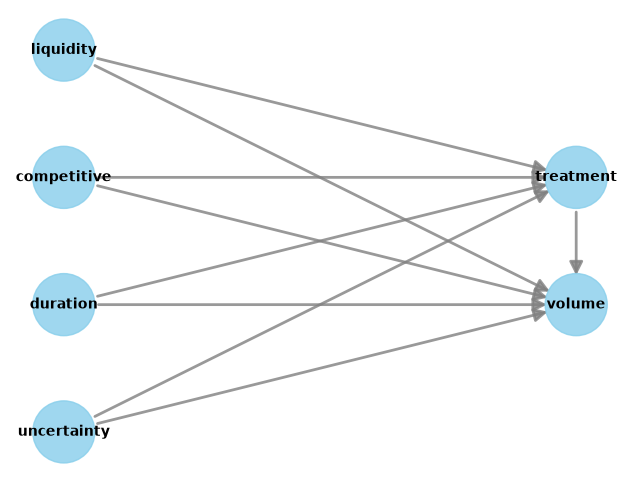

In [18]:
# ─── 2. BUILD DAG ────────────────────────────────────────────────────────────
model = CausalModel(
    data=df_causal,
    treatment='treatment',
    outcome='volume',
    common_causes=['liquidity', 'competitive', 'uncertainty', 'duration']
)

model.view_model()


In [19]:
# ─── 3. IDENTIFY EFFECT ──────────────────────────────────────────────────────
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                            
────────────(E[volume|duration,uncertainty,competitive,liquidity])
d[treatment]                                                      
Estimand assumption 1, Unconfoundedness: If U→{treatment} and U→volume then P(volume|treatment,duration,uncertainty,competitive,liquidity,U) = P(volume|treatment,duration,uncertainty,competitive,liquidity)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
     d                                                            
────────────(E[volume|duration,uncertainty,competitive,liquidity])
d[treatment]                                                      
Estimand assumption 1, Unconfoundedness: If U→{treatment} and U→volume then P

In [20]:
# ─── 4. ESTIMATE CAUSAL EFFECT ───────────────────────────────────────────────
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression"
)
print(f"\nEstimated ATE: {estimate.value:.4f}")
print(estimate)


Estimated ATE: 181746.8872
*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                            
────────────(E[volume|duration,uncertainty,competitive,liquidity])
d[treatment]                                                      
Estimand assumption 1, Unconfoundedness: If U→{treatment} and U→volume then P(volume|treatment,duration,uncertainty,competitive,liquidity,U) = P(volume|treatment,duration,uncertainty,competitive,liquidity)

## Realized estimand
b: volume~treatment+duration+uncertainty+competitive+liquidity
Target units: ate

## Estimate
Mean value: 181746.88716368173



In [21]:
# ─── 5. REFUTATION TESTS ─────────────────────────────────────────────────────
print("\n--- Refutation Test 1: Random Common Cause ---")
refute1 = model.refute_estimate(
    identified_estimand, estimate,
    method_name="random_common_cause"
)
print(refute1)

print("\n--- Refutation Test 2: Placebo Treatment ---")
refute2 = model.refute_estimate(
    identified_estimand, estimate,
    method_name="placebo_treatment_refuter"
)
print(refute2)

print("\n--- Refutation Test 3: Data Subset ---")
refute3 = model.refute_estimate(
    identified_estimand, estimate,
    method_name="data_subset_refuter"
)
print(refute3)


--- Refutation Test 1: Random Common Cause ---
Refute: Add a random common cause
Estimated effect:181746.88716368173
New effect:181747.12859059818
p value:1.0


--- Refutation Test 2: Placebo Treatment ---


/Users/aman/miniforge3/envs/polymarket/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/Users/aman/miniforge3/envs/polymarket/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/Users/aman/miniforge3/envs/polymarket/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/Users/aman/miniforge3/envs/polymarket/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/Users/aman/miniforge3/envs/polymarket/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero 

Refute: Use a Placebo Treatment
Estimated effect:181746.88716368173
New effect:-1762.853292261317
p value:0.8


--- Refutation Test 3: Data Subset ---


/Users/aman/miniforge3/envs/polymarket/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/Users/aman/miniforge3/envs/polymarket/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/Users/aman/miniforge3/envs/polymarket/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/Users/aman/miniforge3/envs/polymarket/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/Users/aman/miniforge3/envs/polymarket/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero 

Refute: Use a subset of data
Estimated effect:181746.88716368173
New effect:181235.7217081417
p value:0.94



/Users/aman/miniforge3/envs/polymarket/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/Users/aman/miniforge3/envs/polymarket/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/Users/aman/miniforge3/envs/polymarket/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/Users/aman/miniforge3/envs/polymarket/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/Users/aman/miniforge3/envs/polymarket/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero 